# ARTI403 – Image Processing
## Lab 1: Basics of Image Representation and Manipulation



In [12]:
# Importing Libraries 
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import numpy as np



## Task #2: Loading and Visualizing Images

[ WARN:0@785.182] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 52545 (0xcd41) encountered


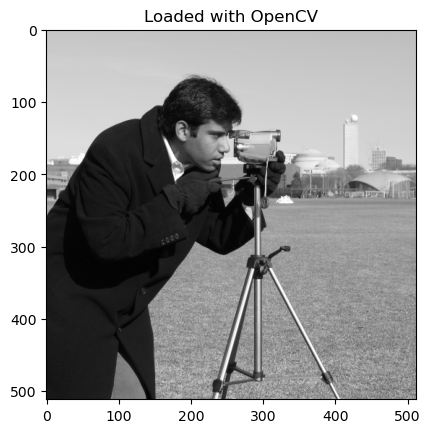

In [26]:
# Load image into a NumPy array (OpenCV reads as BGR by default)
img = cv2.imread('images/cameraman.tif')

# Display the image
plt.imshow(img)
plt.title('Loaded with OpenCV')
plt.show()

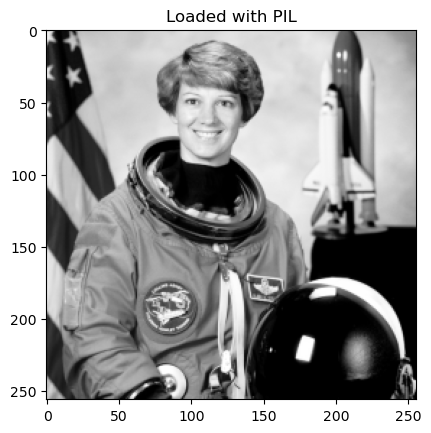

In [22]:
# Load image into a PIL Image object
img2 = Image.open('images/lena_gray_256.tif')

# Display in grayscale
plt.imshow(img2, cmap=cm.Greys_r)
plt.title('Loaded with PIL')
plt.show()

## Task #3: Image Storing

In [15]:
# Save the OpenCV-loaded image to disk
cv2.imwrite('new_image.jpg', img)

# Save the PIL-loaded image to disk
img2.save('new_image2.jpg')

## Task #4: Display Image as an Array

In [10]:
# img is already a NumPy array (loaded via OpenCV)
print(img.shape)
print(img)

(512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


In [27]:
# Convert the PIL image to a NumPy array
img2_array= np.array(img2)
print(img2_array.shape)
print(img2_array)

(256, 256)
[[141  92 116 ... 119 119 116]
 [196 177 183 ... 117 118 117]
 [224 216 210 ... 118 118 118]
 ...
 [171 173 167 ...  61  26   0]
 [172 169 158 ...  47   3   0]
 [170 163 146 ...  76  21   0]]


# Numpy Operations

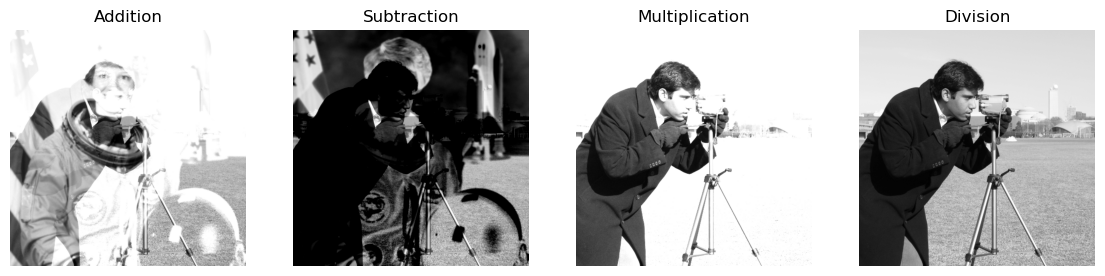

In [32]:
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.int16)                       #
img2_arr = cv2.resize(img2_array, (img1.shape[1], img1.shape[0])).astype(np.int16)  # match img1 size

add_result = np.clip(img1 + img2_arr, 0, 255).astype(np.uint8)  # addition
sub_result = np.clip(img1 - img2_arr, 0, 255).astype(np.uint8)  # subtraction
mul_result = np.clip(img1 * 2, 0, 255).astype(np.uint8)         # multiplication (scalar)
div_result = (img1 / 2).astype(np.uint8)                        # division (scalar)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, im, title in zip(axes, [add_result, sub_result, mul_result, div_result],
                          ['Addition', 'Subtraction', 'Multiplication', 'Division']):
    ax.imshow(im, cmap=cm.Greys_r)
    ax.set_title(title)
    ax.axis('off')
plt.show()